<img src=../figures/Brown_logo.svg width=50%>

## Data-Driven Design & Analyses of Structures & Materials (3dasm)

## Short Course - Lecture 3: Gaussian Process Regression

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor

## Outline for Today

**Part I: From Linear Regression to Gaussian Processes**
- Recap of Bayesian linear regression PPD
- From basis functions to kernel functions
- The RBF kernel and GP definition

**Part II: GP Regression in Practice**
- 1D GP regression with scikit-learn
- Confidence intervals and hyperparameters
- Noisy datasets and learning noise

**Part III: Scaling Up and Hyperparameters**
- Multidimensional GP regression (2D Schwefel function)
- Feature scaling: why it matters
- Scalability and practical considerations

In [1]:
# Basic imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from IPython.display import display, Math

%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8,4)

# Scikit-learn imports
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, ConstantKernel, WhiteKernel
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

---
# Part I: From Linear Regression to Gaussian Processes

*How kernel functions emerge from Bayesian linear regression*

## Recap: PPD for Bayesian Linear Regression

In Lecture 2 we derived the PPD for Bayesian linear regression (assuming zero-mean prior $\overset{\scriptscriptstyle <}{\boldsymbol{\mu}}_w = \mathbf{0}$):

$$\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})} = \mathcal{N}\left(y^* \mid {\boldsymbol{\phi}^*}^T \overset{\scriptscriptstyle >}{\boldsymbol{\Sigma}}_w \frac{1}{\sigma^2}\boldsymbol{\Phi}^T\mathbf{y} \,,\, \sigma^2 + {\boldsymbol{\phi}^*}^T \overset{\scriptscriptstyle >}{\boldsymbol{\Sigma}}_w \boldsymbol{\phi}^*\right)$$

where $\boldsymbol{\phi}^* = \boldsymbol{\phi}(\mathbf{x}^*)$ is the basis function vector at the test point, $\boldsymbol{\Phi}$ is the $N \times M$ design matrix, and $\overset{\scriptscriptstyle >}{\boldsymbol{\Sigma}}_w$ is the posterior covariance of the weights.

Today: we will show that this expression can be rewritten using **kernel functions**!

## Recall: the design matrix

The $N \times M$ design matrix collects the basis functions evaluated at all training points:

$$\boldsymbol{\Phi} = \begin{bmatrix} \phi_0(\mathbf{x}_1) & \phi_1(\mathbf{x}_1) & \cdots & \phi_{M-1}(\mathbf{x}_1) \\
\vdots & \vdots & \ddots & \vdots \\
\phi_0(\mathbf{x}_N) & \phi_1(\mathbf{x}_N) & \cdots & \phi_{M-1}(\mathbf{x}_N) \end{bmatrix}$$

where $N$ is the number of training points and $M$ is the number of basis functions.

## Reformulating the PPD

Define a new $N \times N$ matrix:

$$\mathbf{K} = \boldsymbol{\Phi} \overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\Phi}^T$$

Using this matrix and the [matrix inversion lemma](https://en.wikipedia.org/wiki/Woodbury_matrix_identity), we can rewrite the PPD equivalently as:

$$\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})} = \mathcal{N}\left( y^* \mid {\boldsymbol{\phi}^*}^T \overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\Phi}^T(\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1}\mathbf{y} \,,\, \sigma^2 + {\boldsymbol{\phi}^*}^T \overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\phi}^* - {\boldsymbol{\phi}^*}^T \overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\Phi}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1} \boldsymbol{\Phi}\overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\phi}^*\right)$$

This is mathematically equivalent to the previous slide! (proof uses the Woodbury identity)

## A powerful observation

Let's look carefully at the PPD. Three types of terms appear everywhere:

$$\boldsymbol{\Phi}\overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\Phi}^T \quad , \quad {\boldsymbol{\phi}^*}^T\overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\Phi}^T \quad , \quad {\boldsymbol{\phi}^*}^T\overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\phi}^*$$

All three have the same structure: **basis functions multiplied together** with the prior covariance as a coefficient!

## What do these products look like?

Assuming $\overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w = \overset{\scriptscriptstyle <}{\sigma}_w^2 \mathbf{I}_M$ (diagonal prior), the elements of these matrices are:

**Matrix $\boldsymbol{\Phi}\overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\Phi}^T$** ($N \times N$):
$$A_{ij} = \overset{\scriptscriptstyle <}{\sigma}_w^2 \sum_{m=0}^{M-1} \phi_m(\mathbf{x}_i)\phi_m(\mathbf{x}_j)$$

**Vector ${\boldsymbol{\phi}^*}^T\overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\Phi}^T$** ($1 \times N$):
$$b_j = \overset{\scriptscriptstyle <}{\sigma}_w^2 \sum_{m=0}^{M-1} \phi_m(\mathbf{x}^*)\phi_m(\mathbf{x}_j)$$

**Scalar ${\boldsymbol{\phi}^*}^T\overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w \boldsymbol{\phi}^*$**:
$$c = \overset{\scriptscriptstyle <}{\sigma}_w^2 \sum_{m=0}^{M-1} \phi_m(\mathbf{x}^*)\phi_m(\mathbf{x}^*)$$

All three are governed by one entity: $\overset{\scriptscriptstyle <}{\sigma}_w^2 \sum_m \phi_m(\mathbf{x}_i)\phi_m(\mathbf{x}_j)$

## Hello kernels!

All three terms are governed by a single mathematical entity called a **kernel function** (or Mercer kernel):

$$k(\mathbf{x}_i,\mathbf{x}_j) = \sigma_{w}^2 \sum_{m=0}^{M-1} \phi_m(\mathbf{x}_i) \phi_m(\mathbf{x}_j) = \sigma_{w}^2 \boldsymbol{\phi}(\mathbf{x}_i)^T \boldsymbol{\phi}(\mathbf{x}_j)$$

The kernel measures a notion of **similarity** between two input points $\mathbf{x}_i$ and $\mathbf{x}_j$.

## Example: polynomial kernel

Consider 1D inputs with a quadratic polynomial basis (no bias): $\boldsymbol{\phi}(x)=[x , x^2]$

With $\sigma_w=1$, the kernel is:

$$k(x_i,x_j) = 1 \cdot (x_i \cdot x_j + x_i^2 \cdot x_j^2)= x_i x_j + x_i^2 x_j^2$$

This is a **polynomial kernel** of degree 2.

We compute this for every pair of points $(x_i, x_j)$. If we have $N$ training points, we get an $N \times N$ **covariance matrix** $\mathbf{K}$.

## Why should we care about kernels?

You might be thinking: "If we're using the same basis functions, why bother with this kernel reformulation?"

Great question! The kernel formulation is powerful because:

1. We can **choose kernels directly** without specifying basis functions
2. Some kernels correspond to **infinitely many** basis functions
3. The computational cost depends on $N$ (data points), not $M$ (basis functions)

This is the essence of the **kernel trick**: work in kernel space instead of feature space!

## What happens when $M \rightarrow \infty$?

Something remarkable: if we take the number of basis functions $M \rightarrow \infty$, the kernel function becomes a **Gaussian kernel** (a.k.a. **Radial Basis Function** or RBF kernel, a.k.a. **squared exponential** or SE kernel):

$$k(\mathbf{x}_i,\mathbf{x}_j) = \exp\left( - \frac{||\mathbf{x}_i-\mathbf{x}_j||^2}{2 l^2} \right)$$

where $l$ is the **length scale** of the kernel.

This means GPs can implicitly use **infinitely many basis functions**!

## Intuition: why does $M \rightarrow \infty$ give the RBF kernel?

The key insight comes from the Taylor expansion of the exponential:

$$\exp(\langle \mathbf{x}_i, \mathbf{x}_j \rangle) = \sum_{m=0}^{\infty} \frac{\langle \mathbf{x}_i, \mathbf{x}_j \rangle^m}{m!}$$

Each term $\langle \mathbf{x}_i, \mathbf{x}_j \rangle^m$ is a polynomial kernel of degree $m$.

So the RBF kernel is an **infinite sum of polynomial kernels** of all degrees!

After absorbing constants into the length scale $l$, we get:

$$k(\mathbf{x}_i,\mathbf{x}_j) = \exp\left( - \frac{||\mathbf{x}_i-\mathbf{x}_j||^2}{2 l^2} \right)$$

In [8]:
# Visualize what kernel functions look like
x_kernel = np.linspace(-5, 5, 200)
x_ref = 0.0  # reference point

fig_k, axes_k = plt.subplots(1, 3, figsize=(14, 4))

# RBF kernel with different length scales
for l in [0.5, 1.0, 2.0]:
    k_vals = np.exp(-0.5 * (x_kernel - x_ref)**2 / l**2)
    axes_k[0].plot(x_kernel, k_vals, label=f"$l={l}$")
axes_k[0].set_title("RBF kernel: $k(x, 0)$", fontsize=14)
axes_k[0].set_xlabel("$x$", fontsize=14)
axes_k[0].set_ylabel("$k(x, 0)$", fontsize=14)
axes_k[0].legend(fontsize=12)
axes_k[0].set_ylim(-0.1, 1.1)

# Matérn kernel (nu=1.5) with different length scales
from scipy.spatial.distance import cdist
for l in [0.5, 1.0, 2.0]:
    r = np.abs(x_kernel - x_ref) / l
    k_vals = (1 + np.sqrt(3)*r) * np.exp(-np.sqrt(3)*r)
    axes_k[1].plot(x_kernel, k_vals, label=f"$l={l}$")
axes_k[1].set_title("Matérn ($\\nu=3/2$) kernel: $k(x, 0)$", fontsize=14)
axes_k[1].set_xlabel("$x$", fontsize=14)
axes_k[1].legend(fontsize=12)
axes_k[1].set_ylim(-0.1, 1.1)

# Periodic kernel with different periods
for p in [1.0, 2.0, 4.0]:
    k_vals = np.exp(-2 * np.sin(np.pi * np.abs(x_kernel - x_ref) / p)**2)
    axes_k[2].plot(x_kernel, k_vals, label=f"$p={p}$")
axes_k[2].set_title("Periodic kernel: $k(x, 0)$", fontsize=14)
axes_k[2].set_xlabel("$x$", fontsize=14)
axes_k[2].legend(fontsize=12)
axes_k[2].set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.close(fig_k)

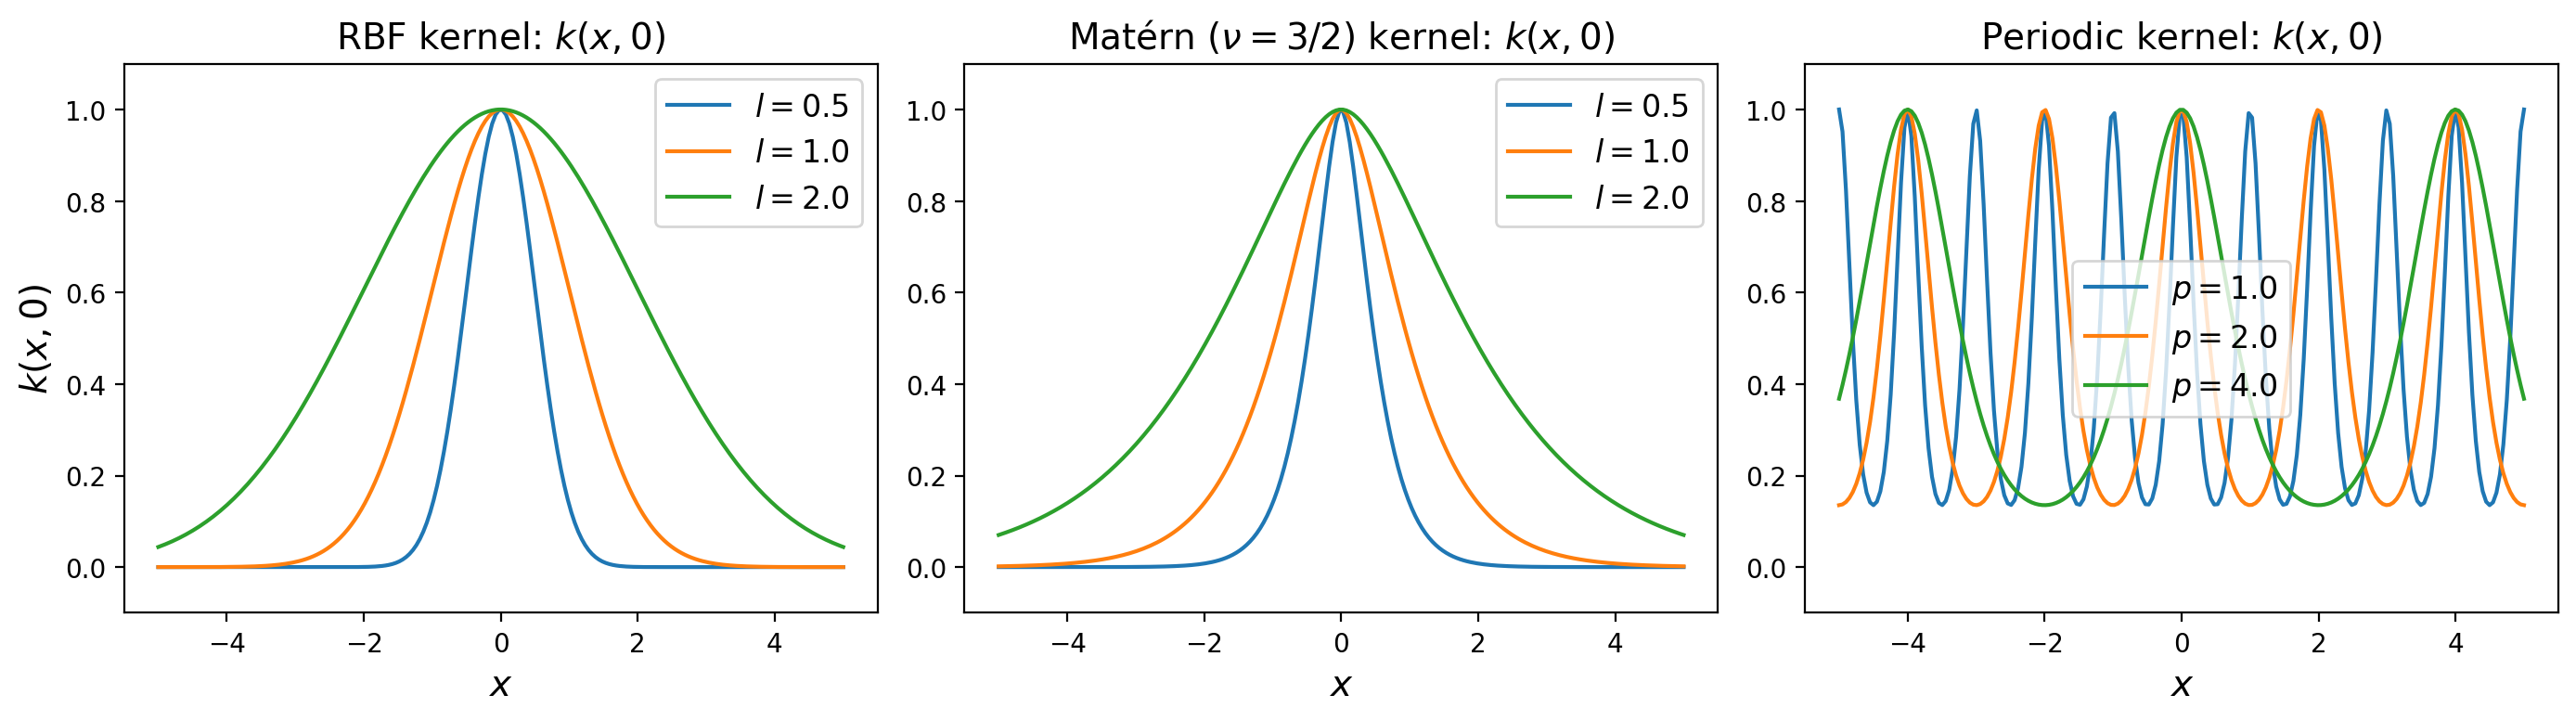

In [9]:
# Plot 3 kernel functions
fig_k

## Gaussian Process Regression

A Gaussian process is simply Bayesian linear regression using nonlinear kernel functions, instead of linear basis functions.

The PPD for a GP with **homoscedastic noise** $\sigma^2$:

$$\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})} = \mathcal{N}\left( y^* \mid \underbrace{{\mathbf{k}^*}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1}\mathbf{y}}_{\text{mean prediction}} \,,\, \underbrace{\sigma^2}_{\text{aleatoric}} + \underbrace{k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1} \mathbf{k}^*}_{\text{epistemic}}\right)$$

**Two types of uncertainty:**
- **Aleatoric** (data noise $\sigma^2$): irreducible — cannot be reduced with more data
- **Epistemic** (model uncertainty): reducible — decreases as we add more training data

## Kernel function, kernel vector, and covariance matrix

The PPD depends on:

**Kernel function**: $k(\mathbf{x}_i, \mathbf{x}_j)$ — a chosen kernel

**Kernel vector**: ${\mathbf{k}^*}^T = [k(\mathbf{x}_1, \mathbf{x}^*), k(\mathbf{x}_2, \mathbf{x}^*), \ldots, k(\mathbf{x}_N, \mathbf{x}^*)]$

**Covariance matrix** ($N \times N$):

$$\mathbf{K} = \begin{bmatrix} k(\mathbf{x}_1, \mathbf{x}_1) & k(\mathbf{x}_1, \mathbf{x}_2) & \cdots & k(\mathbf{x}_1, \mathbf{x}_N) \\
k(\mathbf{x}_2, \mathbf{x}_1) & k(\mathbf{x}_2, \mathbf{x}_2) & \cdots & k(\mathbf{x}_2, \mathbf{x}_N) \\
\vdots & \vdots & \ddots & \vdots \\
k(\mathbf{x}_N, \mathbf{x}_1) & k(\mathbf{x}_N, \mathbf{x}_2) & \cdots & k(\mathbf{x}_N, \mathbf{x}_N) \end{bmatrix}$$

## Kernel catalog

The most common kernel is the **RBF kernel** with two hyperparameters ($s^2$ and $l$):

$$k(\mathbf{x}_i,\mathbf{x}_j) = s^2 \exp\left( - \frac{||\mathbf{x}_i-\mathbf{x}_j||^2}{2 l^2} \right)$$

Other important kernels:
* **Matérn kernel**: less smooth than RBF (limited differentiability)
* **Periodic kernel** (ExpSineSquared): captures repeating structure
* **White kernel**: models noise as $s_2^2 \delta_{ij}$

You can see interactive plots of these kernels [here](https://distill.pub/2019/visual-exploration-gaussian-processes/#MultipleKernels).

## Combining kernels

Given two valid kernels $k_1$ and $k_2$, we can create new kernels:

**Addition** (disjunction of properties):
$$k(\mathbf{x}_i, \mathbf{x}_j) = k_1(\mathbf{x}_i, \mathbf{x}_j) + k_2(\mathbf{x}_i, \mathbf{x}_j)$$

**Multiplication** (conjunction of properties):
$$k(\mathbf{x}_i, \mathbf{x}_j) = k_1(\mathbf{x}_i, \mathbf{x}_j) \times k_2(\mathbf{x}_i, \mathbf{x}_j)$$

Both operations preserve positive-definiteness!

For example: $s^2 \times \text{RBF}$ = ConstantKernel $\times$ RBF kernel.

## General GP PPD

The most general form of the GP PPD includes a **mean function** and **heteroscedastic noise**:

$$\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})} = \mathcal{N}\left( y^* \mid \mu^* + {\mathbf{k}^*}^T (\mathbf{K}+\mathbf{R})^{-1}\mathbf{y} \,,\, {\sigma^*}^2 + k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T (\mathbf{K}+\mathbf{R})^{-1} \mathbf{k}^*\right)$$

where:
- $\mu^* = \mu(\mathbf{x}^*)$ is a **mean function** (usually zero)
- ${\sigma^*}^2 = \sigma^2(\mathbf{x}^*)$ allows **heteroscedastic** (input-dependent) noise
- $\mathbf{R}$ is a diagonal noise matrix: $R_{ij} = \sigma_i^2 \delta_{ij}$

In practice, noise is often absorbed into the kernel (e.g., adding a **White kernel**).

## Summary: the GP PPD

By absorbing noise into the kernel, the GP PPD simplifies to:

$$\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})} = \mathcal{N}\left( y^* \mid {\mathbf{k}^*}^T \mathbf{K}^{-1}\mathbf{y} \,,\, k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T \mathbf{K}^{-1} \mathbf{k}^*\right)$$

For example, a common kernel that includes noise:

$$k(\mathbf{x}_i, \mathbf{x}_j) = \underbrace{\sigma_i^2 \delta_{ij}}_{\text{White kernel (noise)}} + \underbrace{s^2 \exp\left( - \frac{||\mathbf{x}_i-\mathbf{x}_j||^2}{2 l^2} \right)}_{\text{RBF kernel (signal)}}$$

This elegant formulation is what we will implement in Part II!

---
# Part II: GP Regression in Practice

*Learning to use Gaussian processes with scikit-learn*

## 1D Gaussian Process Regression

Let's use the same function from Lecture 2: $f(x) = x \sin(x)$

We will compare GP regression with the polynomial models we trained previously.

In [4]:
# Function to "learn"
def f(x):
    return x * np.sin(x)

n_data = 50
x_data = np.linspace(0, 10, n_data)
y_data = f(x_data)

X_data = np.reshape(x_data, (-1, 1))  # 2D array for scikit-learn

seed = 1987
np.random.seed(seed)

# Train/test split
testset_ratio = 0.90
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=testset_ratio, random_state=seed)

print(f"Training points: {len(X_train)}, Test points: {len(X_test)}")

Training points: 5, Test points: 45


## The most common GP kernel

We will use the most common kernel: Constant $\times$ RBF:

$$k(x_i,x_j) = {\color{red}s}^2\exp{\left(-\frac{||x_i-x_j||^2}{2{\color{red}l}^2}\right)}$$

The entire PPD depends on only **two hyperparameters** ($s^2$ and $l$).

scikit-learn optimizes these hyperparameters automatically using **MLE-II** (Type II Maximum Likelihood Estimation on the marginal likelihood).

## Tutorial: GPR for noiseless data

Let's make our first prediction using Gaussian processes.

Initial guess for hyperparameters: $s = 1$ and $l = 10$.

In [5]:
# Define points used for plotting
n_plot = 500
x_plot = np.linspace(0, 10, n_plot)
X_plot = np.reshape(x_plot, (-1, 1))

# Define the kernel function
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))

# Create and train the GP model
gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10,
                                    optimizer='fmin_l_bfgs_b', n_restarts_optimizer=20)
gp_model.fit(X_train, y_train)

# Predict mean and standard deviation
y_plot_pred, sigma_plot = gp_model.predict(X_plot, return_std=True)

print(f"Optimized kernel: {gp_model.kernel_}")

Optimized kernel: 4.33**2 * RBF(length_scale=1.14)


In [ ]:
# Plot the function, the prediction and the 95% confidence interval
fig1, ax1 = plt.subplots()

ax1.plot(x_plot, f(x_plot), 'r:', label=r'ground truth: $f(x) = x \sin(x)$')
ax1.plot(x_plot, y_plot_pred, 'b-', label="GPR prediction")
ax1.fill(np.concatenate([x_plot, x_plot[::-1]]),
         np.concatenate([y_plot_pred - 1.9600 * sigma_plot,
                        (y_plot_pred + 1.9600 * sigma_plot)[::-1]]),
         alpha=.3, fc='b', ec='None', label='95% confidence interval')
ax1.plot(X_train, y_train, 'r.', markersize=10, label='training points')
ax1.set_xlabel('$x$', fontsize=20)
ax1.set_ylabel('$f(x)$', fontsize=20)
ax1.legend(loc='upper left', fontsize=12)
fig1.set_size_inches(8, 5)

## Understanding GP hyperparameters

Let's explore the effect of the hyperparameters on the GP prediction.

Try the following modifications in the code above:

1. Change the domain to $x \in (-10, 20)$ to see **extrapolation** behavior
2. Turn off the optimizer (`optimizer=None`) and try:
   - $s^2=1, l=10$ (too smooth)
   - $s^2=1, l=1$ (reasonable)
   - $s^2=1, l=0.1$ (too wiggly)
3. Try different kernels: `Matern`, `ExpSineSquared`
4. Turn the optimizer back on and observe the optimized hyperparameters

### In-class Exercise

Fit a polynomial of degree 4 (Linear Least Squares) and compute the $R^2$ and MSE metrics for that model as well as for the Gaussian process model using the RBF kernel.

Which model performs better?

In [ ]:
# Write your code for the In-class Exercise:

# until here.

<details>
<summary><b>Click here for Solution</b></summary>

```python
# Polynomial model
degree = 4
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X_train, y_train)
y_poly_pred = poly_model.predict(X_test)

# GP predictions on test set
y_gp_pred = gp_model.predict(X_test)

# Error metrics
print(f"Polynomial degree {degree}:")
print(f"  MSE = {mean_squared_error(y_test, y_poly_pred):.4f}")
print(f"  R²  = {r2_score(y_test, y_poly_pred):.4f}")
print(f"GP (RBF kernel):")
print(f"  MSE = {mean_squared_error(y_test, y_gp_pred):.4f}")
print(f"  R²  = {r2_score(y_test, y_gp_pred):.4f}")
```
</details>

## GP regression for noisy datasets

In practice, data is noisy. Let's create a noisy version of $f(x)=x\sin(x)$:

$$y = f(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_{\text{noise}}^2(x))$$

where the noise level **varies** across the domain (**heteroscedastic noise**).

In [ ]:
# Create noisy dataset with heteroscedastic noise
noise_std = 0.2 + 1.0 * np.random.random(y_data.shape)
noise_samples = np.random.normal(0, noise_std)
y_noisy_data = y_data + noise_samples

# Pair up points with their associated noise level (for train_test_split)
Y_noisy_data = np.column_stack((y_noisy_data, noise_std))

# Split into train/test
X_train_n, X_test_n, Y_train_n, Y_test_n = train_test_split(
    X_data, Y_noisy_data, test_size=testset_ratio, random_state=seed)

y_noisy_train = Y_train_n[:, 0]
noise_std_train = Y_train_n[:, 1]
y_noisy_test = Y_test_n[:, 0]

# Plot the noisy data
fig2, ax2 = plt.subplots()
ax2.plot(x_data, y_data, 'r:', linewidth=2, label=r'ground truth: $f(x) = x\,\sin(x)$')
ax2.errorbar(x_data, y_noisy_data, noise_std, fmt='kX', markersize=6, label='noisy dataset')
ax2.plot(X_train_n, y_noisy_train, 'g*', markersize=15, label="training points")
ax2.set_xlabel('$x$', fontsize=20)
ax2.set_ylabel('$f(x)$', fontsize=20)
ax2.legend(loc='upper left', fontsize=12)
fig2.set_size_inches(8, 5)

## Learning the noise with a White kernel

When we **don't know** the noise at each training point, we can add a White kernel to learn it as a hyperparameter:

$$k(x_i,x_j) = {\color{red}s_1}^2\exp{\left(-\frac{||x_i-x_j||^2}{2{\color{red}l}^2}\right)} + {\color{red}s_2}^2\delta_{ij}$$

The White kernel $s_2^2 \delta_{ij}$ captures the noise variance.

**Important:** When using a White kernel, set `alpha=0.0` in scikit-learn.

In [ ]:
# GP model with RBF + White kernel to learn the noise
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(
    length_scale=1e-1, length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(
    noise_level=1e-2, noise_level_bounds=(1e-10, 1e1))

# alpha=0.0 because the White Kernel handles the noise!
gp_model_noisy = GaussianProcessRegressor(kernel=kernel, alpha=0.0,
                                          optimizer='fmin_l_bfgs_b', n_restarts_optimizer=20)
gp_model_noisy.fit(X_train_n, y_noisy_train)

# Predict
y_plot_pred_n, sigma_plot_n = gp_model_noisy.predict(X_plot, return_std=True)

print(f"Optimized kernel: {gp_model_noisy.kernel_}")

In [ ]:
# Plot GP predictions with learned noise
fig3, ax3 = plt.subplots()
ax3.plot(x_plot, f(x_plot), 'r:', label=r'ground truth: $f(x) = x\,\sin(x)$')
ax3.plot(x_plot, y_plot_pred_n, 'b-', label="GPR prediction")
ax3.fill(np.concatenate([x_plot, x_plot[::-1]]),
         np.concatenate([y_plot_pred_n - 1.9600 * sigma_plot_n,
                        (y_plot_pred_n + 1.9600 * sigma_plot_n)[::-1]]),
         alpha=.3, fc='b', ec='None', label='95% confidence interval')
ax3.plot(X_train_n, y_noisy_train, 'r.', markersize=10, label='training points')
ax3.set_xlabel('$x$', fontsize=20)
ax3.set_ylabel('$f(x)$', fontsize=20)
ax3.legend(loc='upper left', fontsize=12)
ax3.set_title("GP with learned noise (White kernel)", fontsize=15)
fig3.set_size_inches(8, 5)

---
# Part III: Scaling Up and Hyperparameters

*Multidimensional GP regression and practical considerations*

## Multidimensional GP regression

So far we have only considered 1D inputs. But GPs work with any number of input dimensions!

Let's consider a 2D benchmark function: the **Schwefel function**.

We will use a dataset that was created from this function and saved as a Pandas DataFrame.

In [ ]:
# Define the Schwefel function (for plotting)
def schwefel(x):
    function_name = 'Schwefel'
    x = np.asarray_chkfinite(x)
    if x.ndim == 1:
        x = np.reshape(x, (-1, 2))
    n_points, n_features = np.shape(x)
    y = np.empty((n_points, 1))
    for ii in range(n_points):
        y[ii] = 418.9829 * n_features - sum(x[ii, :] * np.sin(np.sqrt(abs(x[ii, :]))))
    return (np.atleast_1d(y), function_name)

set_cm = cm.cool  # colormap for surface plots

# Create grid for plotting
n_points_per_dimension = 50
x1 = np.linspace(-10.0, 10.0, n_points_per_dimension)
x2 = np.linspace(-10.0, 10.0, n_points_per_dimension)
X1_grid, X2_grid = np.meshgrid(x1, x2)
Data_X = np.column_stack((X1_grid.ravel(), X2_grid.ravel()))
Data_y, function_name = schwefel(Data_X)
Y_grid = np.reshape(Data_y, np.shape(X1_grid))

In [ ]:
# Plot the Schwefel function
fig4 = plt.figure(figsize=plt.figaspect(0.5)); ax4_list = []
# Surface plot
ax4_list.append(fig4.add_subplot(1, 2, 1, projection='3d'))
surf = ax4_list[0].plot_surface(X1_grid, X2_grid, Y_grid,
                                cmap=set_cm, alpha=0.8, linewidth=0, antialiased=False)
ax4_list[0].set_xlabel('$x_1$', fontsize=15)
ax4_list[0].set_ylabel('$x_2$', fontsize=15)
ax4_list[0].set_zlabel('$f(x_1,x_2)$', fontsize=15)
ax4_list[0].set_title("Schwefel function (3D)", fontsize=15)
# Contour plot
ax4_list.append(fig4.add_subplot(1, 2, 2))
cset = ax4_list[1].contourf(X1_grid, X2_grid, Y_grid, cmap=set_cm)
ax4_list[1].set_xlabel('$x_1$', fontsize=15)
ax4_list[1].set_ylabel('$x_2$', fontsize=15)
ax4_list[1].set_title("Schwefel function (contour)", fontsize=15)
fig4.colorbar(cset, ax=ax4_list[1])
fig4.set_size_inches(14, 5)
plt.tight_layout()

In [ ]:
# Load data from pickle file
df = pd.read_pickle("../data/data_noiseless_schwefel_2D_regression.pkl")
print("DataFrame shape:", df.shape)
print(df.head())

# Separate features and targets
X_data_2d = df.loc[:, ['x1', 'x2']].values
y_data_2d = df.loc[:, 'y1'].values

# Train/test split
testset_ratio_2d = 0.98
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_data_2d, y_data_2d, test_size=testset_ratio_2d, random_state=seed)

## Training a GP without scaling the data

Let's first try training a GP on the raw (unscaled) data and see what happens...

In [ ]:
# Train GP on UNSCALED data
kernel_2d = ConstantKernel(1.0, (1e-4, 1e4)) * RBF(10, (1e-2, 1e2))
gp_model_2d = GaussianProcessRegressor(kernel=kernel_2d, alpha=1e-3, n_restarts_optimizer=20)
gp_model_2d.fit(X_train_2d, y_train_2d)

# Predict on entire dataset for plotting
y_data_GPpred, sigma_data_GPpred = gp_model_2d.predict(X_data_2d, return_std=True)
y_test_GPpred = gp_model_2d.predict(X_test_2d)

print(f"R² score (UNSCALED): {r2_score(y_test_2d, y_test_GPpred):.4f}")

In [ ]:
# Plot: ground truth vs UNSCALED GP prediction
fig5 = plt.figure(figsize=plt.figaspect(0.5)); ax5 = []
# Ground truth
ax5.append(fig5.add_subplot(1, 2, 1, projection='3d'))
ax5[0].plot_surface(X1_grid, X2_grid, Y_grid,
                    cmap=set_cm, alpha=0.8, linewidth=0, antialiased=False)
ax5[0].set_xlabel('$x_1$', fontsize=15)
ax5[0].set_ylabel('$x_2$', fontsize=15)
ax5[0].set_zlabel('$f(x_1,x_2)$', fontsize=15)
ax5[0].set_title("Ground truth", fontsize=15)
# GP prediction (WRONG)
ax5.append(fig5.add_subplot(1, 2, 2, projection='3d'))
Y_grid_pred = np.reshape(y_data_GPpred, np.shape(X1_grid))
ax5[1].plot_surface(X1_grid, X2_grid, Y_grid_pred,
                    cmap=set_cm, alpha=0.8, linewidth=0, antialiased=False)
ax5[1].set_xlabel('$x_1$', fontsize=15)
ax5[1].set_ylabel('$x_2$', fontsize=15)
ax5[1].set_zlabel('$f(x_1,x_2)$', fontsize=15)
ax5[1].set_title("GPR prediction (UNSCALED — WRONG!)", fontsize=15)
ax5[1].scatter(X_train_2d[:, 0], X_train_2d[:, 1], y_train_2d,
               marker='o', color='red', label="training points")
ax5[1].legend(loc='upper center')
fig5.set_size_inches(15, 6)

## Why did this fail? Feature scaling!

The output values are large and we did not **pre-process** the dataset appropriately!

It is good practice to **scale the dataset ALWAYS**.

We will use `StandardScaler` from scikit-learn to scale both inputs and outputs to zero mean and unit variance.

In [ ]:
# Scale inputs
scaler_x = StandardScaler()
scaler_x.fit(X_train_2d)
X_train_scaled = scaler_x.transform(X_train_2d)
X_test_scaled = scaler_x.transform(X_test_2d)
X_data_scaled = scaler_x.transform(X_data_2d)

# Scale outputs
y_train_2d_r = y_train_2d.reshape(-1, 1)
y_test_2d_r = y_test_2d.reshape(-1, 1)
y_data_2d_r = y_data_2d.reshape(-1, 1)
scaler_y = StandardScaler()
scaler_y.fit(y_train_2d_r)
y_train_scaled = scaler_y.transform(y_train_2d_r).ravel()
y_test_scaled = scaler_y.transform(y_test_2d_r).ravel()
y_data_scaled = scaler_y.transform(y_data_2d_r).ravel()

print("Scaled training inputs: mean =", X_train_scaled.mean(axis=0).round(2),
      ", std =", X_train_scaled.std(axis=0).round(2))
print("Scaled training outputs: mean =", y_train_scaled.mean().round(2),
      ", std =", y_train_scaled.std().round(2))

In [ ]:
# Train GP on SCALED data (same kernel, same parameters!)
kernel_2d = ConstantKernel(1.0, (1e-4, 1e4)) * RBF(10, (1e-2, 1e2))
gp_model_2d_scaled = GaussianProcessRegressor(kernel=kernel_2d, alpha=1e-3, n_restarts_optimizer=20)
gp_model_2d_scaled.fit(X_train_scaled, y_train_scaled)

# Predict and inverse-transform back to original scale
y_data_GPpred_sc, sigma_data_GPpred_sc = gp_model_2d_scaled.predict(X_data_scaled, return_std=True)
y_data_GPpred = scaler_y.inverse_transform(y_data_GPpred_sc.reshape(-1, 1))
sigma_data_GPpred = scaler_y.inverse_transform(sigma_data_GPpred_sc.reshape(-1, 1)) - np.mean(y_train_2d)

# Predict for test set
y_test_GPpred_sc = gp_model_2d_scaled.predict(X_test_scaled)
y_test_GPpred = scaler_y.inverse_transform(y_test_GPpred_sc.reshape(-1, 1))

print(f"R² score (SCALED): {r2_score(y_test_2d, y_test_GPpred):.4f}")

In [ ]:
# Plot: ground truth vs SCALED GP prediction
fig6 = plt.figure(figsize=plt.figaspect(0.5)); ax6 = []
# Ground truth
ax6.append(fig6.add_subplot(1, 2, 1, projection='3d'))
ax6[0].plot_surface(X1_grid, X2_grid, Y_grid,
                    cmap=set_cm, alpha=0.8, linewidth=0, antialiased=False)
ax6[0].set_xlabel('$x_1$', fontsize=15)
ax6[0].set_ylabel('$x_2$', fontsize=15)
ax6[0].set_zlabel('$f(x_1,x_2)$', fontsize=15)
ax6[0].set_title("Ground truth", fontsize=15)
# GP prediction (CORRECT)
ax6.append(fig6.add_subplot(1, 2, 2, projection='3d'))
Y_grid_pred = np.reshape(y_data_GPpred, np.shape(X1_grid))
ax6[1].plot_surface(X1_grid, X2_grid, Y_grid_pred,
                    cmap=set_cm, alpha=0.8, linewidth=0, antialiased=False)
ax6[1].set_xlabel('$x_1$', fontsize=15)
ax6[1].set_ylabel('$x_2$', fontsize=15)
ax6[1].set_zlabel('$f(x_1,x_2)$', fontsize=15)
ax6[1].set_title("GPR mean (SCALED — CORRECT)", fontsize=15)
ax6[1].scatter(X_train_2d[:, 0], X_train_2d[:, 1], y_train_2d.ravel(),
               marker='o', color='red', label="training points")
ax6[1].legend(loc='upper center')
fig6.set_size_inches(15, 6)

In [ ]:
# Contour plots: ground truth, GP mean, and GP uncertainty
fig7 = plt.figure(figsize=plt.figaspect(0.5)); ax7 = []

# Ground truth contour
ax7.append(fig7.add_subplot(1, 3, 1))
cset = ax7[0].contourf(X1_grid, X2_grid, Y_grid, cmap=set_cm)
ax7[0].set_xlabel('$x_1$', fontsize=15)
ax7[0].set_ylabel('$x_2$', fontsize=15)
ax7[0].set_title("Ground truth", fontsize=15)
fig7.colorbar(cset, ax=ax7[0])

# GP mean contour
ax7.append(fig7.add_subplot(1, 3, 2))
Y_grid_pred = np.reshape(y_data_GPpred, np.shape(X1_grid))
cset = ax7[1].contourf(X1_grid, X2_grid, Y_grid_pred, cmap=set_cm)
ax7[1].set_xlabel('$x_1$', fontsize=15)
ax7[1].set_ylabel('$x_2$', fontsize=15)
ax7[1].set_title("GPR mean", fontsize=15)
fig7.colorbar(cset, ax=ax7[1])

# GP uncertainty contour
ax7.append(fig7.add_subplot(1, 3, 3))
SIGMA_grid = np.reshape(sigma_data_GPpred, np.shape(X1_grid))
cset = ax7[2].contourf(X1_grid, X2_grid, SIGMA_grid, cmap=set_cm)
ax7[2].set_xlabel('$x_1$', fontsize=15)
ax7[2].set_ylabel('$x_2$', fontsize=15)
ax7[2].set_title("GPR std. deviation", fontsize=15)
fig7.colorbar(cset, ax=ax7[2])

plt.tight_layout()
fig7.set_size_inches(15, 5)

## Scalability: an important limitation

Gaussian processes have a computational complexity of $\mathcal{O}(N^3)$ for training (due to inverting the $N \times N$ covariance matrix).

This means:
* $N = 100$ training points → fast
* $N = 1{,}000$ training points → a few seconds
* $N = 10{,}000$ training points → very slow
* $N = 100{,}000+$ training points → impractical

For large datasets, consider **sparse GP approximations** or other ML methods (e.g., neural networks).

### In-class Exercise

Modify the `testset_ratio_2d` variable above to use more training data (e.g., change from 0.98 to 0.90, then 0.75) and re-run the GP.

1. How does the $R^2$ metric improve?
2. How does the uncertainty (standard deviation) change?
3. How does the training time change?

In [ ]:
# Write your code for the In-class Exercise:

# until here.

<details>
<summary><b>Click here for Solution</b></summary>

```python
import time

for ratio in [0.98, 0.90, 0.75]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_data_2d, y_data_2d, test_size=ratio, random_state=seed)
    # Scale
    sx = StandardScaler().fit(X_tr)
    sy = StandardScaler().fit(y_tr.reshape(-1,1))
    X_tr_s = sx.transform(X_tr)
    X_te_s = sx.transform(X_te)
    y_tr_s = sy.transform(y_tr.reshape(-1,1)).ravel()
    # Train
    k = ConstantKernel(1.0, (1e-4, 1e4)) * RBF(10, (1e-2, 1e2))
    gp = GaussianProcessRegressor(kernel=k, alpha=1e-3, n_restarts_optimizer=20)
    t0 = time.time()
    gp.fit(X_tr_s, y_tr_s)
    t1 = time.time()
    # Evaluate
    y_pred_s = gp.predict(X_te_s)
    y_pred = sy.inverse_transform(y_pred_s.reshape(-1,1))
    r2 = r2_score(y_te, y_pred)
    print(f"test_ratio={ratio:.2f}, N_train={len(X_tr):4d}, "
          f"R²={r2:.4f}, time={t1-t0:.1f}s")
```
</details>

## Key Takeaways from Lecture 3

**Part I: From Linear Regression to GPs**
- GPs emerge from Bayesian linear regression by replacing basis functions with **kernel functions**
- The RBF kernel corresponds to infinitely many basis functions
- Kernels can be combined via addition and multiplication

**Part II: GP Regression in Practice**
- GPs provide **uncertainty quantification** via confidence intervals
- The **White kernel** allows learning noise from data
- GPs outperform polynomial regression on complex functions

**Part III: Scaling Up**
- **Always scale your data** before training a GP
- GPs scale as $\mathcal{O}(N^3)$ — limited to moderate dataset sizes

## Next Lecture

**Lecture 4: Classification and Artificial Neural Networks**

- From regression to classification
- Logistic regression and softmax
- Introduction to neural networks

---

### Thank you!

Questions?